CPP Pricing Engine<br>
Alejandro Naranjo Caraza<br>
2026-03-01

#### Overview

The following presents the basic assumptions regarding stock price behaviour in option valuation. The Black-Scholes-Merton (BSM) model and the Binomial Tree model propose similar ideas regarding stock price fluctuations, but, while BSM is based on a continuous process (a Geometric Brownian Motion, specifically), the Binomial Model follows a discrete-time, discrete-state random walk.

#### Relevant Models

<u>Stochastic Process</u>

A stochastic process is a family of random variables

$$
\{X(t) : t \in T\}
$$

defined on a probability space, where the index set $T$ typically represents time.

A stochastic process is called a *continuous-time, continuous-state stochastic process* if the index set $T$ is continuous (e.g., $T \subseteq \mathbb{R}$) and each random variable $X(t)$ takes values in a continuous state space (e.g., $\mathbb{R}$).

<u>Random Walk</u>

A *discrete-time* random walk can be defined as a stochastic process $\{S_n : n=0,1,2,..\}$ where $S_n$ is the sum of random independant and identically distributed random variables (steps) $X_i$:
$$
S_n = S_0 + \sum_{i=1}^{n}X_i
$$

Note the the next position depends only on the previous one (Markov property): $S_{n+1} = S_n + X_{n+1}$.

<u>Wiener Process / Brownian Motion</u>

Real-valued continuous-time stochastic process $\{W_t\}_{t \ge 0}$ with the following properties:

1. $W_0 = 0$ almost surely.
2. $W$ has independent increments. For every $t > 0$, the future increments $W_{t+u}-W_t$,$\quad u\ge 0$,
   are independent of the past values $W_s$, $s < t$.
3. $W$ has Gaussian increments. For all $u,t \ge 0$, $W_{t+u} - W_t \sim \mathcal{N}(0,u)$.<br>
   That is, a time step $u$ results in an increment that is normally distributed with mean $0$ and variance $u$.
4. $W$ has almost surely continuous paths: $W_t$ is almost surely continuous in $t$.

<u>Generalized Weiner Process</u>

A *Generalized Weiner Process* for a variable $x$ can be defined
$$
dx = a dt + b dz
$$
where
- $z$ follows a Weiner Process
- $a$ and $b$ are constants
- The mean change per unit change in time (*drift rate*) is $a$
- The variance per unit time is (*variance rate*) is $b²$

<u>Ito's Process</u>

Generalization of *Generalized Weiner Process*:
$$
dx = a(x,t) dt + b(x,t) dz
$$
where $a=a(x,t)$ and $b=b(x,t)$ are deterministic function of $(x,t)$.

#### Stock Price Behaviour Assumptions in Black-Scholes-Merton

Under BSM, stock price follows a **Geometric Brownian Motion**:

$$
\begin{align}
dS &= \mu S dt + \sigma S dz \\
\dfrac{dS}{S} &= \mu dt + \sigma dz
\end{align}
$$

Where

- $S$ is the stock price
- $t$ is the time variable (usually in years)
- $z$ follows a standard Wiener process with <i>drift rate</i> $0$ and <i>variance rate</i> $1$
- $\mu$ is the stock's expected return
- $\sigma$ is stock return volatility ($\sigma²$ is the variance rate of the retun's process)

Notice that, under this model, stock return follows a **Generalized Weiner Process** ($dS = a dt + b dz$). This is because investor's expected return is independent of the stock's price, meaning that constant expected price drift must be replaced by constant return.<br>
Considering $dz = 0$ and integrating between time $0$ and $T$ yields $S_T = S_0 e^{\mu T} $.

Also notice that BSM assumes consistent return uncertainty, independant of stock price, for periods of time of the same length ($dt$).

The discrete-time version of the model is:
$$
\begin{align}
\Delta S &= \mu S \Delta t + \sigma S \epsilon \sqrt{\Delta t} \\
\dfrac{\Delta S}{S} &= \mu \Delta t + \sigma \epsilon \sqrt{\Delta t}
\end{align}
$$
where $\epsilon$ follows a standard normal distribution.

$\Delta S / S$ is approximately normal:
$$\Delta S / S \approx N (\mu \Delta t, \sigma² \Delta t)$$

It can be shown that the log return is exactly normal:
$$\ln(\dfrac{S + \Delta S}{S}) \sim N ((\mu - \dfrac{1}{2}\sigma²)\Delta t, \sigma² \Delta t)$$

#### Stock Price Behaviour Under Binomial Model

Under the Binomial Model, stock price follows a *discrete-time* *discrete-spce* random walk.
At each time step, the stock price $S_n$ can either move up to $S_{n+1}=u S_n$ or down to $S_{n+1}=d S_n$ (with $d<1$, $u>1$). The probability of a price increase is $p$, while the probability of a decrease is $1-p$.

This results in the following expected price at each time step: $E[S_{n+1}] = p (u S_n) + (1-p) (d S_n)$.<br>
Under the no-arbitrage assumption in the binomial model, the probability $p$ in a *risk-neutral framework* is determined by 
$$p = \dfrac{e^{rT}-d}{u-d}$$
where $r$ is the risk-free rate.

<u> John C. Cox, Stephen A. Ross, and Mark Rubinstein (CRR) Parameterization</u>

The following parameterization is commonly adopted because it matches the volatility of the underlying asset and guarantees convergence of the binomial model to the Black–Scholes–Merton framework as $\Delta t$ tends to zero.
$$
\begin{align}
p &= \dfrac{a-d}{u-d}\\
u &= e^{\sigma\sqrt{\Delta t}}\\
d &= e^{-\sigma\sqrt{\Delta t}}\\
a &= e^{r\Delta t}
\end{align}
$$

where

- $r$ is the risk-free rate
- $\sigma$ is the stock return volatility
- $a$ is the discount rate

<u>Binomial Model Pseudocode</u>

In [136]:
import numpy as np
import random
import matplotlib.pyplot as plt

def stockRandomWalk(
    S0,
    T,
    r,
    sigma,
    n_paths = 1,
    n_steps = 100,
    seed = None
):
    if seed is not None:
        np.random.seed(seed)
        
    dt = T/n_steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u
    a = np.exp(r*dt)
    p = (a-d) / (u-d)
    
    bernoulli = np.random.binomial(n=1,p=p,size=(n_paths,n_steps))
    moves = bernoulli * u + (1 - bernoulli) * d
    
    prices = np.empty((n_paths,n_steps + 1))
    prices[:,0] = S0
    prices[:,1:] = S0 * np.cumprod(moves,axis=1)

    return prices

def stockGbmEuler(
    S0,
    T,
    r,
    sigma,
    n_paths = 1,
    n_steps = 100,
    seed = None
):
    if seed is not None:
        np.random.seed(seed)
        
    dt = T/n_steps
    sqrt_dt = np.sqrt(dt)
    eps = np.random.normal(loc=0,scale=1,size=(n_paths,n_steps))
    prices = np.zeros((n_paths,n_steps+1))
    prices[:,0] = S0
    prices[:,1:] = S0 * np.cumprod(1 + r*dt + sigma*eps*sqrt_dt,axis=1)
    return prices

def stockGbmExact(
    S0,
    T,
    r,
    sigma,
    n_paths = 1,
    n_steps = 100,
    seed = None
):
    if seed is not None:
        np.random.seed(seed)
    
    dt = T/n_steps
    sqrt_dt = np.sqrt(dt)
    eps = np.random.normal(loc=0,scale=1,size=(n_paths,n_steps))
    prices = np.zeros((n_paths,n_steps + 1))
    prices[:,0] = S0
    prices[:,1:] = S0 * np.cumprod(np.exp((r-sigma**2/2)*dt + (sigma*sqrt_dt*eps)),axis=1)
    return prices

In [149]:
S0 = 50
T = 10
r = 0.1
sigma = 0.2
n_paths = 10
n_steps = 100

p0 = stockRandomWalk(S0,T,r,sigma,n_paths,n_steps)
p1 = stockGbmEuler(S0,T,r,sigma,n_paths,n_steps)
p2 = stockGbmExact(S0,T,r,sigma,n_paths,n_steps)

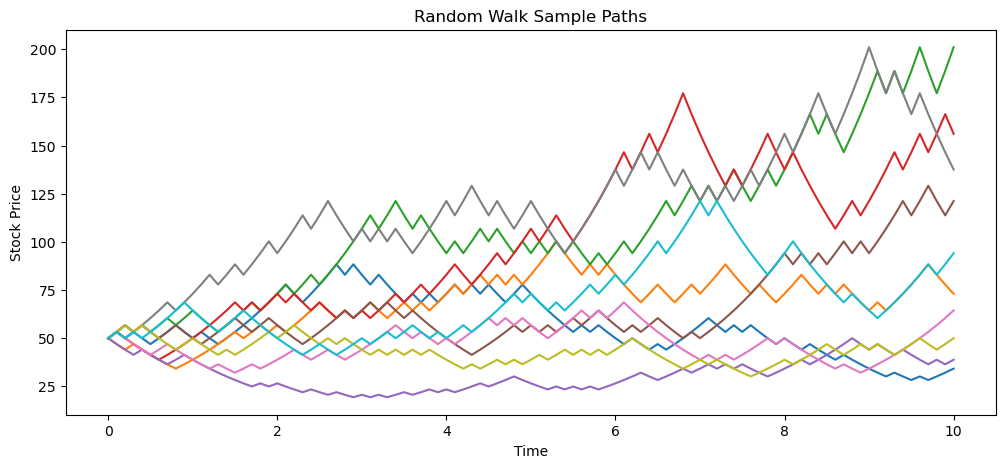

In [155]:
time = np.linspace(0, T, n_steps + 1)

plt.figure(figsize=(12, 5))
plt.plot(time, p0.T)
plt.title("Random Walk Sample Paths")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.show()

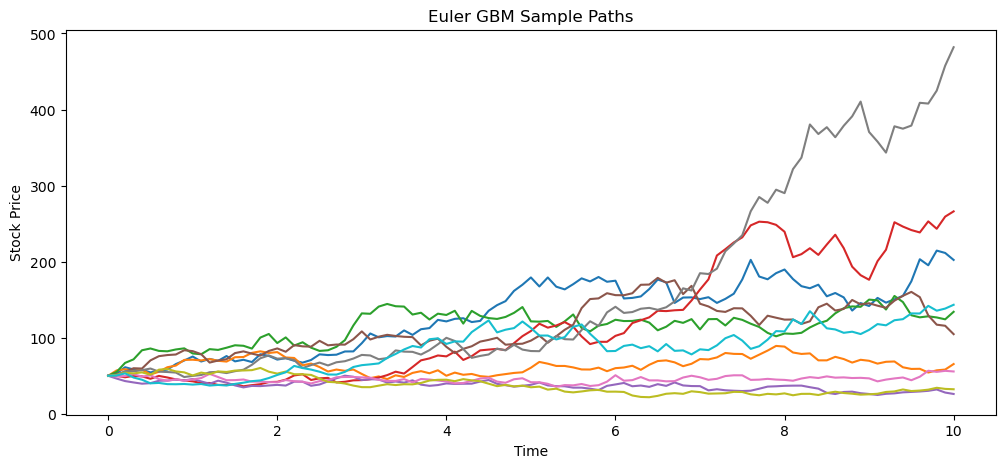

In [156]:
plt.figure(figsize=(12, 5))
plt.plot(time, p1.T)
plt.title("Euler GBM Sample Paths")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.show()

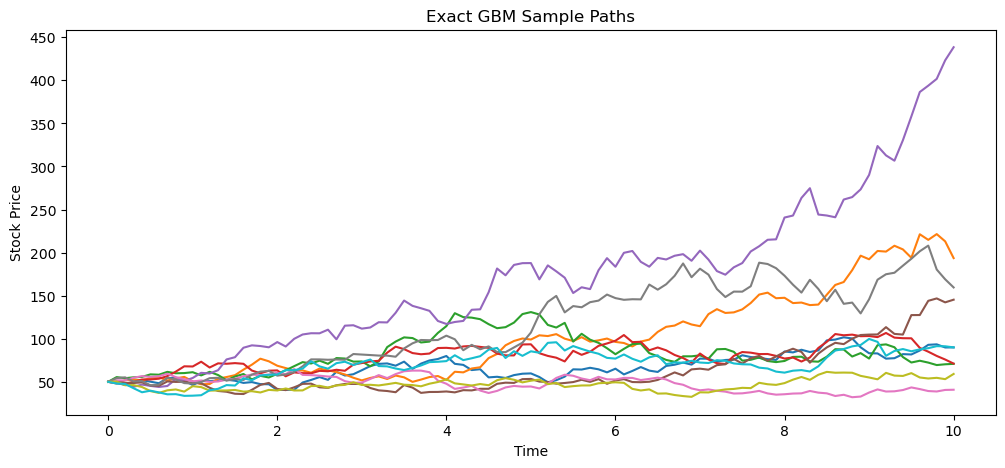

In [157]:
plt.figure(figsize=(12, 5))
plt.plot(time, p2.T)
plt.title("Exact GBM Sample Paths")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.show()